[env: optonpx]

# 2.3 Inspect traces

Plot chosen channels over a chosen time range of a `continuous.dat` — the raw Open Ephys
recording or the notebook 2.2 output — side by side with the result of each processing
step (CAR, filters). One column per stage: raw, after step 1, after step 2, ...

- CAR is computed over **all** good channels in the file, not only the plotted ones.
- Filters are zero-phase Butterworth (`sosfiltfilt`); data is read with a margin on both
  sides and trimmed after filtering, so the window edges are clean.
- `steps = "ks4"` reproduces Kilosort 4's default preprocessing (kilosort/io.py
  `BinaryFiltered.filter`): per-channel mean removal, median CAR, 3rd-order 300 Hz high-pass.
- Files are only opened read-only (`np.memmap(mode="r")`); nothing is written.

The last cell (off by default) scans for events that deflect most channels at once.

In [1]:
from pathlib import Path
import yaml

# ======== parameters to change ========
# any int16 continuous.dat: raw Open Ephys or notebook 2.2 output
dat_path = Path(r"E:\D1-1-6_IM-1979\ephys\2026-09-04\probeB\continuous.dat")
fs = 30000.0
n_chan = 384
bit_volts = 0.195           # uV per bit (NP2.0 / Open Ephys: 0.195)

# metadata: only the bad-channel list of this probe is read from it (None = no bad channels)
metadata_path = Path.cwd().parent / "metadata" / "IM-1979_2026-09-04.yaml"
probe_name = "probeB"

# optional raw Open Ephys session folder, only used for channel geometry (depth order,
# per-shank CAR) from its settings.xml / structure.oebin. For a 2.2 output, point it at
# one of its source sessions. None = plot in channel-index order, global CAR only.
oe_session_dir = None   # e.g. Path(r"D:/D1-1-6_IM-1979/ephys/2026-09-11_14-50-36")

t_start = 4971.20        # seconds from the start of the dat file
t_end = 4972.50
channels = range(80, 120)   # channel indices as in the dat file (0-based), or "all"

steps = [
    ("car", dict(operator="median", by_shank=False)),
    ("highpass", dict(freq=300.0, order=3)),
]
# steps = "ks4"
# other steps: ("center", {}), ("lowpass", dict(freq=300.0, order=3)),
#              ("bandpass", dict(freq=(300.0, 6000.0), order=3)), ("car", dict(operator="mean", by_shank=True))

plot_mode = "traces"         # "traces" (stacked, few-tens of channels) or "heatmap" (many channels)
spacing_uv = None            # traces only: None = auto per column, a number = same for all columns,
                             # or a list with one value per column
exclude_bad_channels = True  # drop metadata bad channels from the plot and from the CAR
# ======================================

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
sys.path.append("..")
from src import oe_parse_folders, oe_parse_params

%matplotlib inline

dat = np.memmap(dat_path, dtype="int16", mode="r").reshape(-1, n_chan)   # read-only

bad_channels = set()
if exclude_bad_channels and metadata_path is not None:
    with open(metadata_path) as f:
        bad_channels = set(yaml.safe_load(f)[probe_name]["kilosort_params"]["bad_channels"])
good_channels = np.array([c for c in range(n_chan) if c not in bad_channels])

# geometry only (fs / channel count / bit_volts stay as set in the parameter cell)
if oe_session_dir is not None:
    _, oe_paths = oe_parse_folders(oe_session_dir)
    probe_params_list, _ = oe_parse_params(oe_paths["xml"], oe_paths["oebin"])
    probe_params = next(p for p in probe_params_list
                        if str(p["stream_name"]).split(".")[-1].lower() == probe_name.lower())
    shank = np.array([probe_params["channel_shank"][c] for c in range(n_chan)])
    depth = np.array([probe_params["channel_ypos"][c] for c in range(n_chan)], dtype=float)
else:
    shank = np.zeros(n_chan, dtype=int)
    depth = np.arange(n_chan, dtype=float)

print(f"{dat_path}  ({dat.shape[0] / fs:.1f} s, {n_chan} ch, fs={fs:.0f}, bit_volts={bit_volts})")
print(f"{len(bad_channels)} bad channels excluded; channel order: "
      f"{'depth from ' + str(oe_session_dir) if oe_session_dir is not None else 'channel index'}")

E:\D1-1-6_IM-1979\ephys\2026-09-04\probeB\continuous.dat  (8904.8 s, 384 ch, fs=30000, bit_volts=0.195)
5 bad channels excluded; channel order: channel index


In [3]:
KS4_STEPS = [("center", {}),
             ("car", dict(operator="median", by_shank=False)),
             ("highpass", dict(freq=300.0, order=3))]


def resolve_steps(steps):
    return KS4_STEPS if steps == "ks4" else list(steps)


def margin_seconds(steps):
    # long enough for the slowest filter's transient to die out before the plotted window
    cutoffs = [min(np.atleast_1d(kw["freq"])) for name, kw in steps if name in ("highpass", "lowpass", "bandpass")]
    return max(0.05, 10.0 / min(cutoffs)) if cutoffs else 0.0


def load_window(t0, t1, margin_s):
    """All channels of [t0 - margin, t1 + margin] in uV, shape (n_samples, n_chan), plus trim indices."""
    s0 = int(round(t0 * fs))
    s1 = int(round(t1 * fs))
    m = int(round(margin_s * fs))
    a, b = max(s0 - m, 0), min(s1 + m, dat.shape[0])
    if s0 < 0 or s1 > dat.shape[0] or s1 <= s0:
        raise ValueError(f"time range {t0}-{t1} s is outside the file")
    x = np.asarray(dat[a:b], dtype=np.float32) * bit_volts
    return x, slice(s0 - a, s0 - a + (s1 - s0))


def apply_step(x, name, kw):
    x = x.copy()
    if name == "center":
        x -= x.mean(axis=0, keepdims=True)
    elif name == "car":
        if kw.get("by_shank", False) and oe_session_dir is None:
            raise ValueError("per-shank CAR needs channel geometry: set oe_session_dir")
        reduce =np.median if kw.get("operator", "median") == "median" else np.mean
        groups = [good_channels[shank[good_channels] == s] for s in np.unique(shank[good_channels])] \
            if kw.get("by_shank", False) else [good_channels]
        targets = [np.flatnonzero(shank == shank[g[0]]) for g in groups] \
            if kw.get("by_shank", False) else [np.arange(n_chan)]
        for g, target in zip(groups, targets):
            x[:, target] -= reduce(x[:, g], axis=1, keepdims=True)
    elif name in ("highpass", "lowpass", "bandpass"):
        sos = butter(kw.get("order", 3), kw["freq"], btype=name, fs=fs, output="sos")
        x = sosfiltfilt(sos, x, axis=0).astype(np.float32)
    else:
        raise ValueError(f"unknown step {name!r}")
    return x


def step_label(name, kw):
    if name == "car":
        return f"CAR {kw.get('operator', 'median')}" + (" per shank" if kw.get("by_shank") else "")
    if name in ("highpass", "lowpass", "bandpass"):
        return f"{name} {kw['freq']} Hz (order {kw.get('order', 3)})"
    return name


def compute_stages(t0, t1, steps):
    steps = resolve_steps(steps)
    x, keep = load_window(t0, t1, margin_seconds(steps))
    stages = {"raw": x[keep]}
    labels = []
    for name, kw in steps:
        x = apply_step(x, name, kw)
        labels.append(step_label(name, kw))
        stages[" + ".join(labels)] = x[keep]
    return stages


def plot_traces(t0, t1, channels="all", steps=(), mode="traces", spacing_uv=None, clim_uv=None):
    """One column per stage. For display only, each channel's median over the window is removed."""
    chans = good_channels if isinstance(channels, str) and channels == "all" else \
        np.array([c for c in channels if c in set(good_channels)])
    chans = chans[np.lexsort((chans, depth[chans], shank[chans]))]   # shank, then depth
    stages = compute_stages(t0, t1, steps)
    t = t0 + np.arange(next(iter(stages.values())).shape[0]) / fs

    n = len(stages)
    height = min(max(3.0, 0.18 * len(chans)), 16) if mode == "traces" else 7
    spacings = list(spacing_uv) if isinstance(spacing_uv, (list, tuple)) else [spacing_uv] * n
    if len(spacings) != n:
        raise ValueError(f"spacing_uv list needs {n} values (one per column), got {len(spacings)}")
    # (c) thinner lines for longer windows: 0.6 at <=0.1 s, down to 0.25 at >=0.24 s
    lw = float(np.clip(0.06 / (t1 - t0), 0.25, 0.6))
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, height), sharex=True, squeeze=False)
    for ax, (name, x), spacing in zip(axes[0], stages.items(), spacings):
        x = x[:, chans] - np.median(x[:, chans], axis=0, keepdims=True)
        if mode == "traces":
            if not spacing:
                lo, hi = np.percentile(x, [0.5, 99.5], axis=0)
                spacing = 1.2 * float(np.median(hi - lo)) or 1.0
            for i in range(len(chans)):
                ax.plot(t, x[:, i] + i * spacing, lw=lw, color="k")
            step = max(1, len(chans) // 25)
            ax.set_yticks(np.arange(0, len(chans), step) * spacing, chans[::step], fontsize=7)
            ax.set_ylim(-spacing, len(chans) * spacing)
            ax.set_title(f"{name}\n(spacing {spacing:.0f} uV)", fontsize=9)
        elif mode == "heatmap":
            clim = clim_uv or float(np.percentile(np.abs(x), 99.5)) or 1.0
            ax.imshow(x.T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-clim, vmax=clim,
                      extent=[t[0], t[-1], -0.5, len(chans) - 0.5], interpolation="nearest")
            step = max(1, len(chans) // 25)
            ax.set_yticks(np.arange(0, len(chans), step), chans[::step], fontsize=7)
            for edge in np.flatnonzero(np.diff(shank[chans])) + 0.5:
                ax.axhline(edge, color="k", lw=0.5)
            ax.set_title(f"{name}\n(colour +/-{clim:.0f} uV)", fontsize=9)
        else:
            raise ValueError(f"mode must be 'traces' or 'heatmap', got {mode!r}")
        ax.set_xlabel("time (s)")
    axes[0, 0].set_ylabel("channel (shank, depth order)")
    fig.suptitle(str(dat_path), fontsize=10)
    fig.tight_layout()
    plt.show()
    return fig

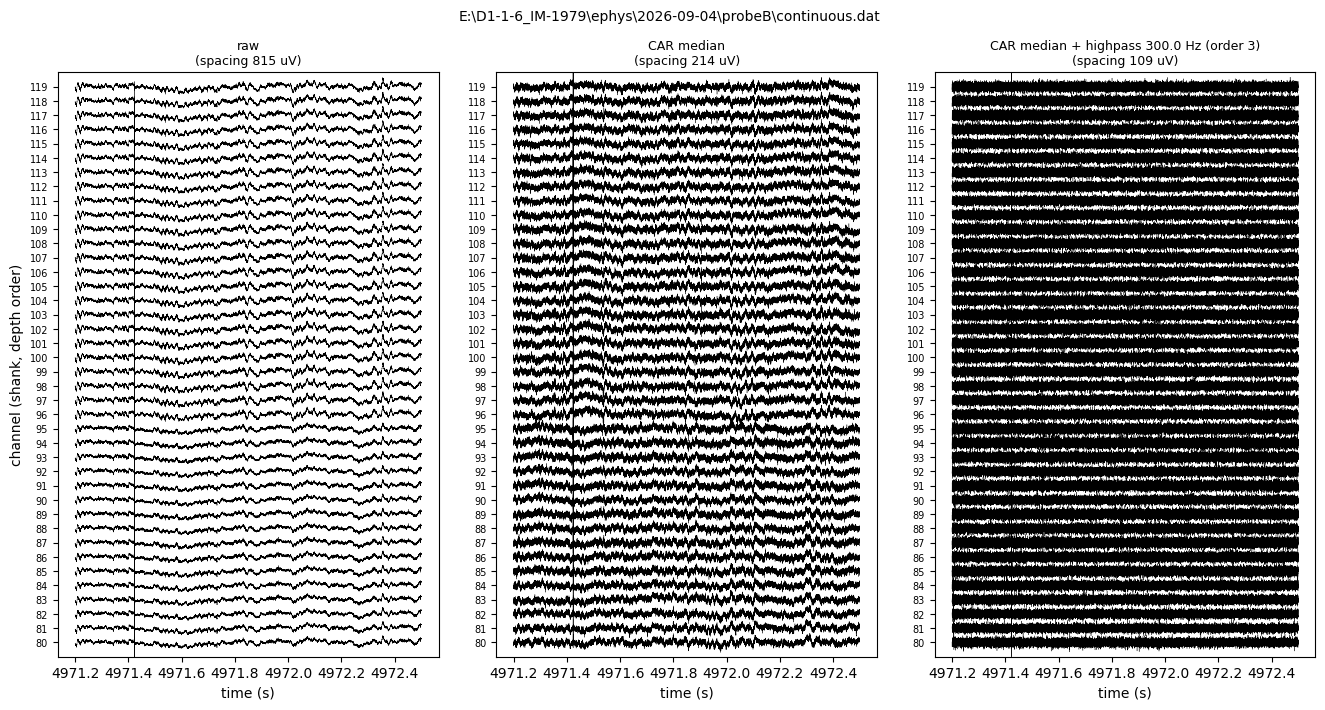

In [4]:
fig = plot_traces(t_start, t_end, channels=channels, steps=steps, mode=plot_mode, spacing_uv=spacing_uv)

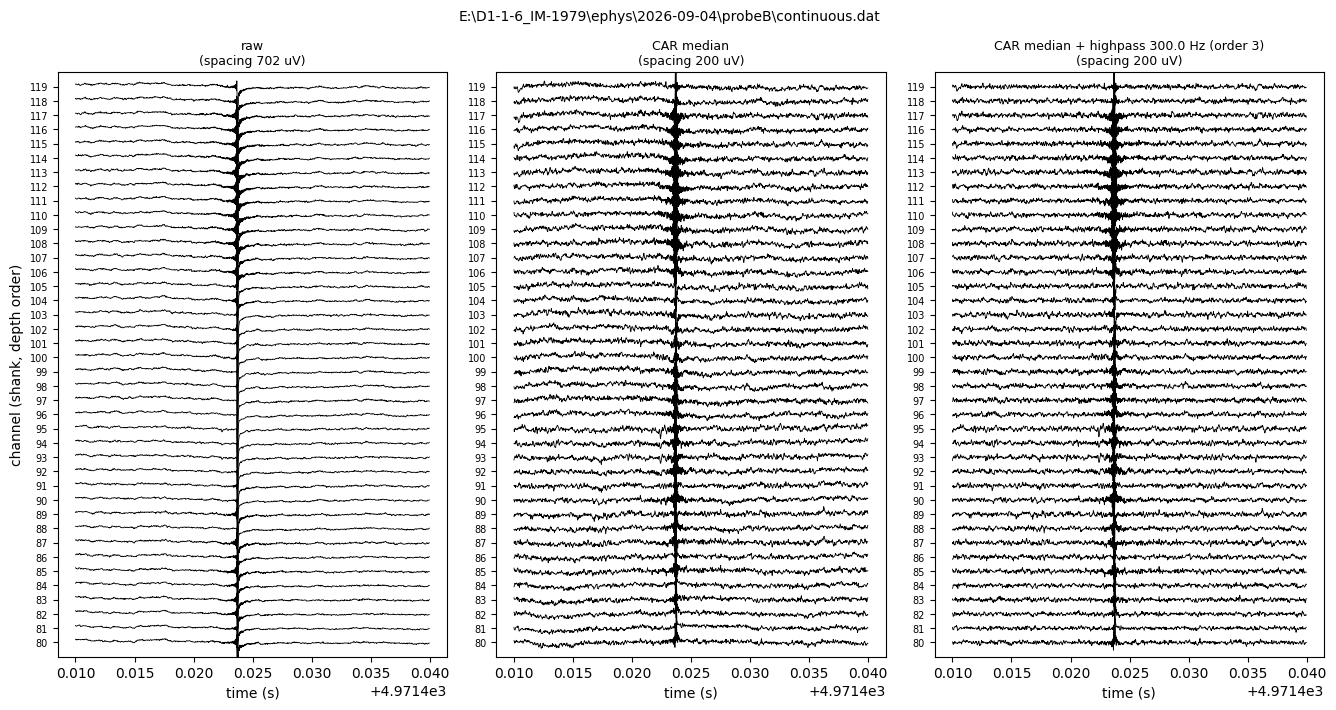

In [5]:
# zoom on the artifact at ~4971.42 s; CAR and CAR+HP columns share one spacing for absolute comparison
fig = plot_traces(4971.41, 4971.44, channels=range(80, 120), steps=steps, spacing_uv=[None, 200, 200])

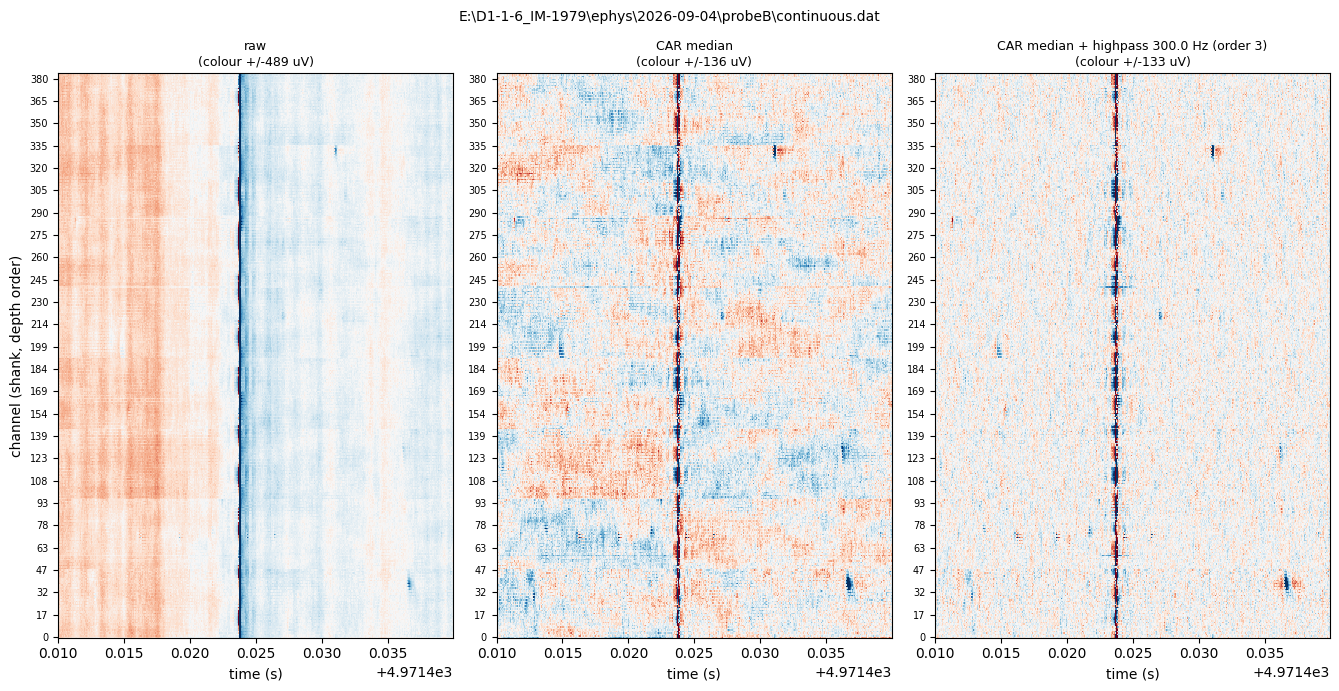

In [6]:
# same window, all channels: is the artifact uniform across the probe?
fig = plot_traces(4971.41, 4971.44, channels="all", steps=steps, mode="heatmap")

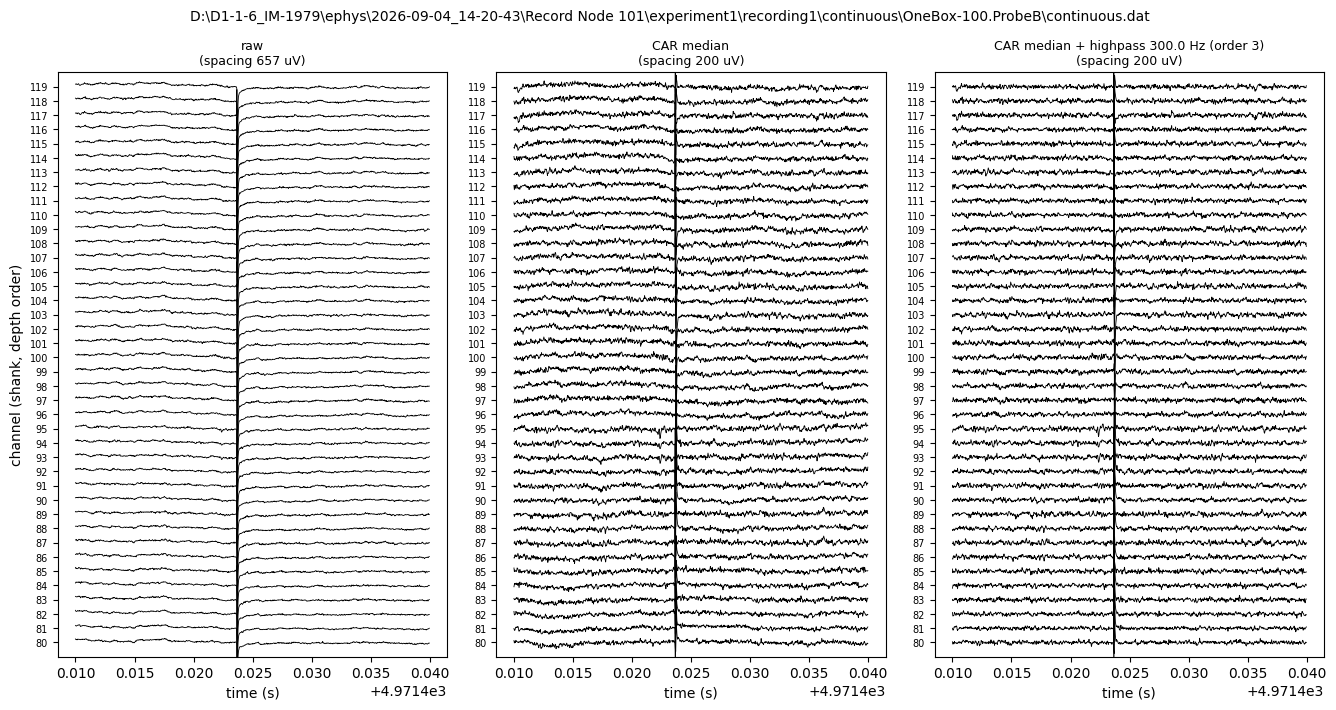

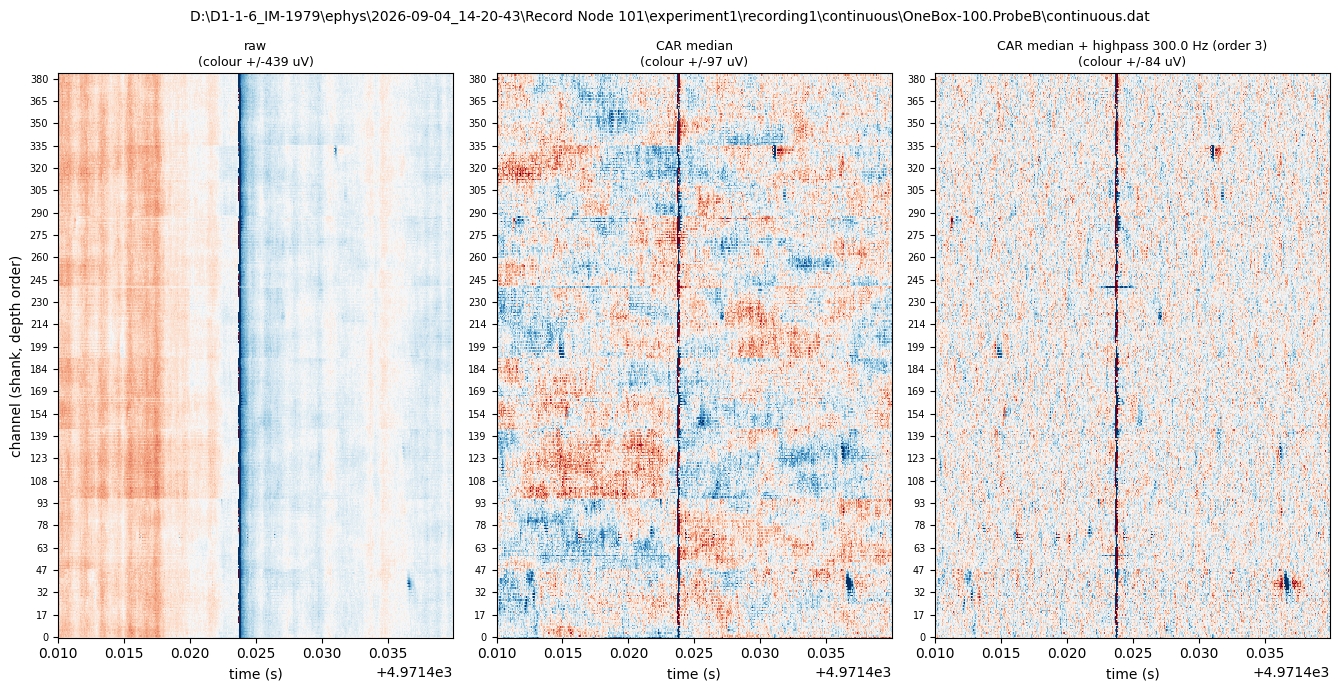

after CAR median + highpass 300.0 Hz (order 3): median-over-channels RMS (uV)
  2.2 output (phase shifted)   event +/-1 ms:  100.0   quiet:  17.8   ratio:  5.6
  raw OE (no phase shift)      event +/-1 ms:   98.5   quiet:  17.8   ratio:  5.5


In [7]:
# same window from the raw Open Ephys file (no phase shift, no laser mask) vs the 2.2 output above.
# The event is in the behavior session, which starts at sample 0 of the 2.2 file -> same time in both.
raw_oe_dat_path = Path(r"D:/D1-1-6_IM-1979/ephys/2026-09-04_14-20-43/Record Node 101/experiment1/recording1/continuous/OneBox-100.ProbeB/continuous.dat")
t0_cmp, t1_cmp = 4971.41, 4971.44
event_win = (4971.4227, 4971.4247)    # +/-1 ms around the transient
quiet_win = (4971.410, 4971.420)      # reference noise, before the transient


def residual_rms(stages, win):
    x = list(stages.values())[-1][:, good_channels]                  # last stage (CAR + HP)
    i0, i1 = int((win[0] - t0_cmp) * fs), int((win[1] - t0_cmp) * fs)
    return float(np.median(np.sqrt(np.mean(x[i0:i1] ** 2, axis=0))))  # median over channels of RMS


processed_dat, processed_dat_path = dat, dat_path
results = {}
try:
    for label, p in [("2.2 output (phase shifted)", processed_dat_path), ("raw OE (no phase shift)", raw_oe_dat_path)]:
        dat, dat_path = np.memmap(p, dtype="int16", mode="r").reshape(-1, n_chan), p
        st = compute_stages(t0_cmp, t1_cmp, steps)
        results[label] = (residual_rms(st, event_win), residual_rms(st, quiet_win))
        if label.startswith("raw"):
            fig = plot_traces(t0_cmp, t1_cmp, channels=range(80, 120), steps=steps, spacing_uv=[None, 200, 200])
            fig = plot_traces(t0_cmp, t1_cmp, channels="all", steps=steps, mode="heatmap")
finally:
    dat, dat_path = processed_dat, processed_dat_path

print(f"after {list(st)[-1]}: median-over-channels RMS (uV)")
for label, (ev, quiet) in results.items():
    print(f"  {label:28s} event +/-1 ms: {ev:6.1f}   quiet: {quiet:5.1f}   ratio: {ev / quiet:4.1f}")

## Optional: scan for events that deflect most channels at once

Off by default (`run_event_scan = False`). Reads the file in 1 s chunks (a few minutes per
300 s), high-passes each chunk (no CAR — CAR would remove exactly what we look for) and
marks samples where at least `detect_min_fraction` of the good channels exceed
`detect_threshold_mad` MADs. Real spikes are local and never do this.
`frac_after_ks4` = the same measure after Kilosort 4's preprocessing: events where it stays
high are the ones Kilosort's CAR does not remove. Plot one with
`plot_traces(peak_s - 0.02, peak_s + 0.04, steps="ks4", mode="heatmap")`.

In [8]:
run_event_scan = False
scan_start_s, scan_duration_s = 0.0, 300.0
detect_threshold_mad = 8.0
detect_min_fraction = 0.5
merge_gap_ms = 2.0

if run_event_scan:
    import pandas as pd
    detect_steps = [("center", {}), ("highpass", dict(freq=300.0, order=3))]
    rng = np.random.default_rng(0)
    file_dur = dat.shape[0] / fs

    def mad_noise(steps, n=10):
        starts = rng.uniform(0.1, file_dur - 1.2, n)
        parts = [apply_step_chain(*load_window(s, s + 1.0, margin_seconds(steps)), steps) for s in starts]
        x = np.concatenate(parts)[:, good_channels]
        return np.median(np.abs(x - np.median(x, axis=0)), axis=0) / 0.6745

    def apply_step_chain(x, keep, steps):
        for name, kw in steps:
            x = apply_step(x, name, kw)
        return x[keep]

    threshold = detect_threshold_mad * mad_noise(detect_steps)
    frac = []
    t = scan_start_s
    scan_end = min(scan_start_s + scan_duration_s, file_dur - 0.1)
    while t < scan_end:
        t1 = min(t + 1.0, scan_end)
        x = apply_step_chain(*load_window(t, t1, margin_seconds(detect_steps)), detect_steps)
        frac.append((np.abs(x[:, good_channels]) > threshold).mean(axis=1))
        if int(t - scan_start_s) % 30 == 0:
            print(f"  {t - scan_start_s:6.0f} / {scan_end - scan_start_s:.0f} s")
        t = t1
    frac = np.concatenate(frac)

    idx = np.flatnonzero(frac >= detect_min_fraction)
    events = []
    if len(idx):
        for run in np.split(idx, np.flatnonzero(np.diff(idx) > int(merge_gap_ms / 1000 * fs)) + 1):
            peak = run[np.argmax(frac[run])]
            events.append(dict(start_s=scan_start_s + run[0] / fs, peak_s=scan_start_s + peak / fs,
                               duration_ms=(run[-1] - run[0] + 1) / fs * 1000, peak_fraction=float(frac[peak])))
    events = pd.DataFrame(events, columns=["start_s", "peak_s", "duration_ms", "peak_fraction"])

    ks4_threshold = detect_threshold_mad * mad_noise(KS4_STEPS)
    events["frac_after_ks4"] = [
        float((np.abs(apply_step_chain(*load_window(p - 0.001, p + 0.001, margin_seconds(KS4_STEPS)), KS4_STEPS)
                      [:, good_channels]) > ks4_threshold).mean(axis=1).max())
        for p in events["peak_s"]]
    print(f"{len(events)} events in {scan_end - scan_start_s:.0f} s; "
          f"{(events['frac_after_ks4'] > 0.1).sum()} still deflect >10% of channels after KS4 preprocessing")
    display(events.sort_values("frac_after_ks4", ascending=False).head(20))